In [22]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict,Literal,Annotated
from pydantic import Field,BaseModel
from langchain_core.messages import SystemMessage,HumanMessage
import operator

In [23]:
from langchain_groq import ChatGroq

generation_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    
)

evaluation_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    
)

optimization_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    
)

In [24]:
class TweetEvaluation(BaseModel):
    evalution: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [25]:
structure_eval_llm=evaluation_llm.with_structured_output(TweetEvaluation)

In [26]:
class Tweet(TypedDict):
    topic:str
    tweet:str
    evalution:Literal['approved','need_improvement']
    feedback:str
    iteration:int
    max_iteration:int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [27]:
def generate_tweet(state:Tweet):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = generation_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [28]:
def evalution_tweet(state:Tweet):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structure_eval_llm.invoke(messages)

    return {'evalution':response.evalution, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


In [29]:
def optimize_tweet(state:Tweet):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimization_llm .invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [30]:
def route_evaluation(state: Tweet):

    if state['evalution'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [31]:
graph=StateGraph(Tweet)
graph.add_node('generate',generate_tweet)
graph.add_node('optimize',optimize_tweet)
graph.add_node('evalution',evalution_tweet)
graph.add_edge(START,'generate')
graph.add_edge('generate','evalution')
graph.add_conditional_edges('evalution',route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize','evalution')
workflow=graph.compile()





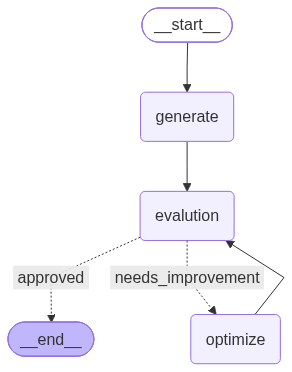

In [32]:
workflow

In [43]:
initial_state = {
    "topic": "Egbbeq",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [44]:
result


{'topic': 'Egbbeq',
 'tweet': 'Egbbeq is the mysterious “extra spice” my grandma adds to everything—so vague it could be love, sarcasm, or the leftover pizza from 2019. Now I’m just waiting for the day it shows up on a menu and finally makes sense. #EgbbeqLife',
 'evalution': 'approved',
 'feedback': "This tweet is a masterclass in originality, with the mysterious 'Egbbeq' concept sparking curiosity and humor. The punchline about waiting for it to show up on a menu is unexpected and delightful, making it genuinely smile-inducing. The tweet's format is also well-executed, being concise and scroll-stopping. The use of the hashtag #EgbbeqLife adds a touch of personality and virality potential. Overall, this tweet checks all the boxes, with its unique blend of humor, originality, and punchiness making it a standout. The only potential weakness is that some readers might not fully understand the context or reference, but the tweet's cleverness and creativity make up for it.",
 'iteration': 